# 🗑️ Smart Waste Sorting System
## Transfer Learning: EfficientNetV2S vs MobileNetV2 vs ResNet50

**Dataset:** Garbage Classification V2 — 12,259 images across 10 classes

| Class | Recyclability |
|---|---|
| cardboard | ♻️ Recycle |
| glass | ♻️ Recycle |
| metal | ♻️ Recycle |
| paper | ♻️ Recycle |
| plastic | ♻️ Recycle |
| biological | ⚫️ Landfill |
| battery | ⚠️ Special Disposal |
| shoes | ⚫️ Landfill |
| clothes | ⚫️ Landfill |
| trash | ⚫️ Landfill |

**Dataset:** https://www.kaggle.com/datasets/sumn2u/garbage-classification-v2

## Cell 1 — Install & Import Libraries

In [5]:
# Installing Libraries
!pip install -q tqdm

import os, time, copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.pyplot as plt
import copy


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from tqdm import tqdm

print('Libraries imported successfully!')

Libraries imported successfully!


## Cell 2 — Configuration

In [14]:
import os
import zipfile
import torch

#  CORE CONFIGURATION — all globals defined here

IMG_SIZE      = 224
BATCH_SIZE    = 32
NUM_EPOCHS    = 10
LEARNING_RATE = 0.001
TRAIN_SPLIT   = 0.70
VAL_SPLIT     = 0.15
TEST_SPLIT    = 0.15
RANDOM_SEED   = 42
DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CLASS_NAMES = [
    'battery', 'biological', 'cardboard',
    'clothes', 'glass', 'metal',
    'paper', 'plastic', 'shoes', 'trash'
]
NUM_CLASSES = len(CLASS_NAMES)

RECYCLABILITY_MAP = {
    'cardboard' : ('RECYCLE',          '♻️'),
    'glass'     : ('RECYCLE',          '♻️'),
    'metal'     : ('RECYCLE',          '♻️'),
    'paper'     : ('RECYCLE',          '♻️'),
    'plastic'   : ('RECYCLE',          '♻️'),
    'biological': ('LANDFILL',         '⚫️'),
    'clothes'   : ('LANDFILL',         '⚫️'),
    'shoes'     : ('LANDFILL',         '⚫️'),
    'trash'     : ('LANDFILL',         '⚫️'),
    'battery'   : ('SPECIAL DISPOSAL', '⚠️'),
}

print(f'Device        : {DEVICE}')
print(f'Classes       : {NUM_CLASSES}')
print(f'Batch size    : {BATCH_SIZE}')
print(f'Epochs        : {NUM_EPOCHS}')
print(f'Learning rate : {LEARNING_RATE}')
print(f'Image size    : {IMG_SIZE}x{IMG_SIZE}')

#  DATASET DOWNLOAD (Kaggle environment)
#
#  On Kaggle, the kaggle CLI is pre-installed.
#  Authentication uses KAGGLE_USERNAME and
#  KAGGLE_KEY env vars set automatically in secrets.

BASE_PATH    = '/kaggle/working/garbage_classification'
DATASET_PATH = '/kaggle/working/garbage_classification/original'
ZIP_FILE     = '/kaggle/working/garbage-classification-v2.zip'

if not os.path.exists(DATASET_PATH):
    print('\n Downloading dataset from Kaggle...')
    os.system(
        'kaggle datasets download -d sumn2u/garbage-classification-v2 '
        '-p /kaggle/working/'
    )
    print('Extracting...')
    with zipfile.ZipFile(ZIP_FILE, 'r') as z:
        z.extractall(BASE_PATH)
    os.remove(ZIP_FILE)
    print(f'Dataset ready at {DATASET_PATH}')
else:
    print(f'\nDataset already exists at {DATASET_PATH}, skipping download.')

# Verify
print(f'\n Class folders in {DATASET_PATH}:')
total = 0
for cls in sorted(os.listdir(DATASET_PATH)):
    cls_path = os.path.join(DATASET_PATH, cls)
    if os.path.isdir(cls_path):
        count = len(os.listdir(cls_path))
        total += count
        print(f'   {cls:<15}: {count} images')
print(f'\n   Total: {total} images')

Device        : cuda
Classes       : 10
Batch size    : 32
Epochs        : 10
Learning rate : 0.001
Image size    : 224x224

Dataset already exists at /kaggle/working/garbage_classification/original, skipping download.

 Class folders in /kaggle/working/garbage_classification/original:
   battery        : 756 images
   biological     : 699 images
   cardboard      : 1411 images
   clothes        : 1892 images
   glass          : 1736 images
   metal          : 930 images
   paper          : 1336 images
   plastic        : 1597 images
   shoes          : 1449 images
   trash          : 453 images

   Total: 12259 images


## Cell 3 — Visualise Sample Images per Class

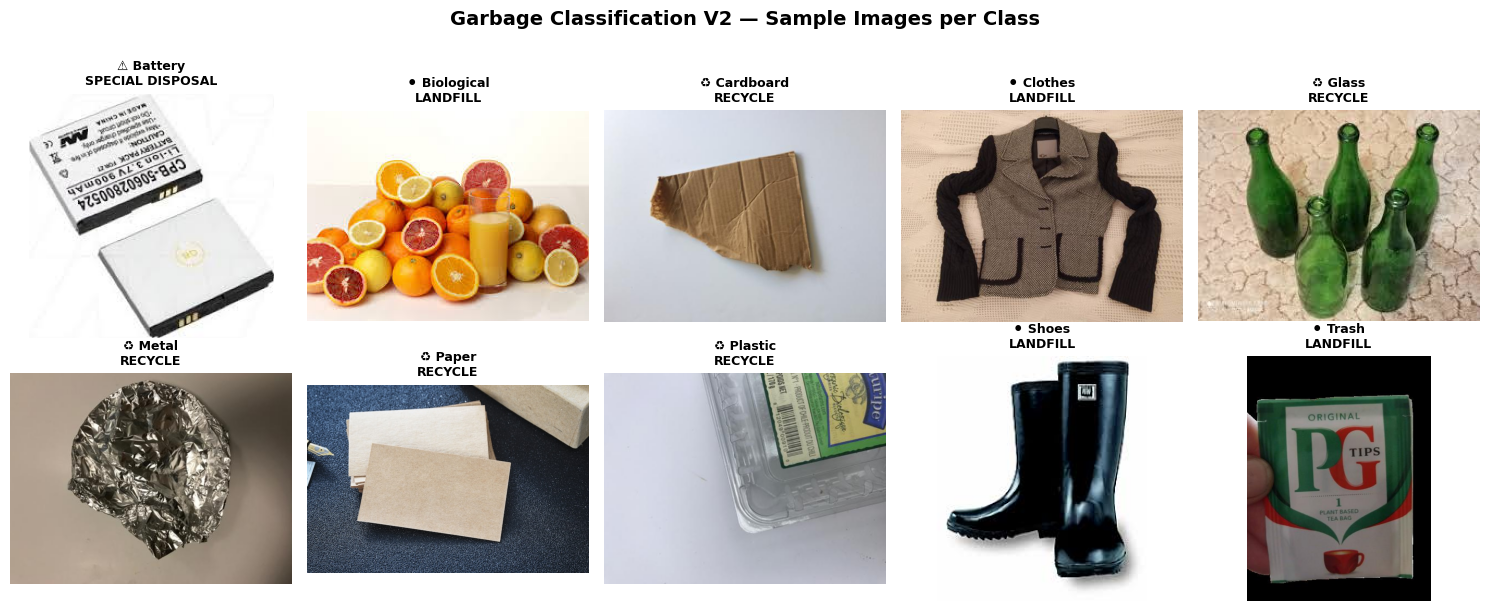

Saved: sample_images.png


In [15]:
DATASET_PATH = '/kaggle/working/garbage_classification/original'

def show_sample_images(data_dir):
    classes = sorted([
        d for d in os.listdir(data_dir)
        if os.path.isdir(os.path.join(data_dir, d))
    ])

    cols = 5
    rows = (len(classes) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 3))
    fig.suptitle('Garbage Classification V2 — Sample Images per Class',
                 fontsize=14, fontweight='bold', y=1.01)

    for idx, cls in enumerate(classes):
        ax = axes[idx // cols][idx % cols]
        cls_path = os.path.join(data_dir, cls)
        img_file = os.listdir(cls_path)[0]
        img      = plt.imread(os.path.join(cls_path, img_file))
        recyclability, icon = RECYCLABILITY_MAP.get(cls, ('UNKNOWN', '❓'))
        ax.imshow(img)
        ax.set_title(f'{icon} {cls.capitalize()}\n{recyclability}', fontsize=9, fontweight='bold')
        ax.axis('off')

    for idx in range(len(classes), rows * cols):
        axes[idx // cols][idx % cols].axis('off')

    plt.tight_layout()
    plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: sample_images.png')

show_sample_images(DATASET_PATH)

## Cell 4 — Class Distribution Chart

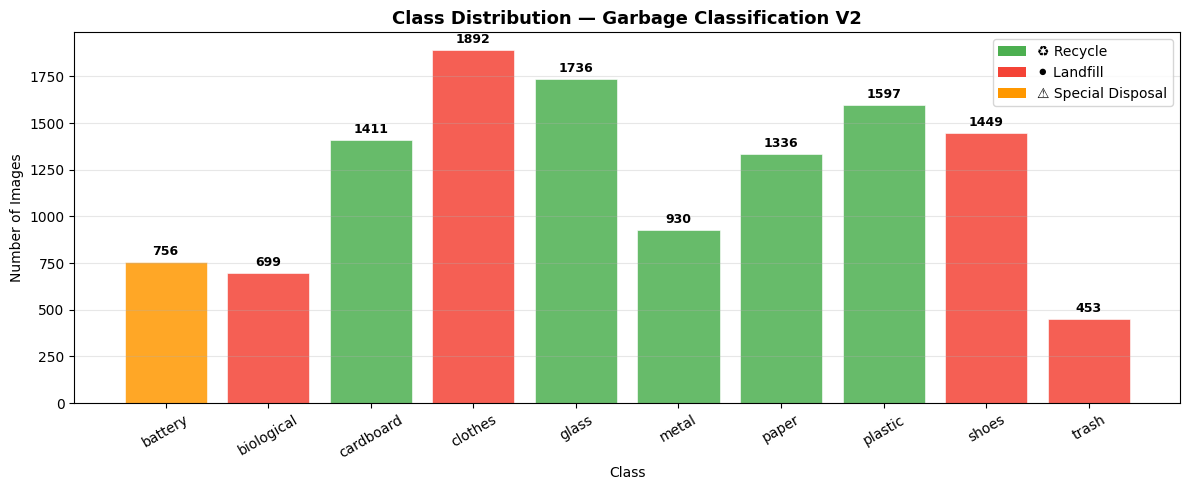

Saved: class_distribution.png


In [17]:
def plot_class_distribution(data_dir):
    classes = sorted([
        d for d in os.listdir(data_dir)
        if os.path.isdir(os.path.join(data_dir, d))
    ])
    counts = [len(os.listdir(os.path.join(data_dir, c))) for c in classes]
    colors = ['#4CAF50' if RECYCLABILITY_MAP.get(c, ('',))[0] == 'RECYCLE'
              else '#F44336' if RECYCLABILITY_MAP.get(c, ('',))[0] == 'LANDFILL'
              else '#FF9800' for c in classes]

    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(classes, counts, color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)

    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                str(count), ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title('Class Distribution — Garbage Classification V2', fontsize=13, fontweight='bold')
    ax.set_xlabel('Class'); ax.set_ylabel('Number of Images')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#4CAF50', label='♻️ Recycle'),
        Patch(facecolor='#F44336', label='⚫️ Landfill'),
        Patch(facecolor='#FF9800', label='⚠️ Special Disposal'),
    ]
    ax.legend(handles=legend_elements, loc='upper right')

    plt.tight_layout()
    plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: class_distribution.png')

plot_class_distribution(DATASET_PATH)

## Cell 5 — Data Transforms & Augmentation

**Design decision:** Training applies augmentation (flip, rotate, colour jitter) to improve generalisation on imbalanced classes. Validation and test use only resize + normalise — no augmentation — to prevent data leakage.

**ImageNet normalisation** is used because all three models were pretrained on ImageNet.

In [18]:
def get_transforms():
    imagenet_mean = [0.485, 0.456, 0.406]
    imagenet_std  = [0.229, 0.224, 0.225]

    train_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(p=0.1),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.RandomGrayscale(p=0.05),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    ])

    val_test_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    ])

    return train_transform, val_test_transform

print('Transforms defined!')

Transforms defined!


## Cell 6 — Load & Split Dataset (70 / 15 / 15)

In [19]:
def load_datasets(data_dir):
    train_tf, val_test_tf = get_transforms()

    full_dataset = datasets.ImageFolder(root=data_dir, transform=train_tf)

    # Update CLASS_NAMES to match actual folder order detected by ImageFolder
    global CLASS_NAMES
    CLASS_NAMES = full_dataset.classes
    print(f'Classes detected by ImageFolder: {CLASS_NAMES}')

    total      = len(full_dataset)
    train_size = int(TRAIN_SPLIT * total)
    val_size   = int(VAL_SPLIT   * total)
    test_size  = total - train_size - val_size

    torch.manual_seed(RANDOM_SEED)
    train_ds, val_ds, test_ds = random_split(
        full_dataset, [train_size, val_size, test_size]
    )

    # Override transforms for val/test — no augmentation
    val_ds.dataset  = copy.deepcopy(full_dataset)
    test_ds.dataset = copy.deepcopy(full_dataset)
    val_ds.dataset.transform  = val_test_tf
    test_ds.dataset.transform = val_test_tf

    print(f'\nDataset Split')
    print(f'  Total  : {total}')
    print(f'  Train  : {train_size}')
    print(f'  Val    : {val_size}')
    print(f'  Test   : {test_size}')

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = load_datasets(DATASET_PATH)
print('\n Data loaders ready!')

Classes detected by ImageFolder: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']

Dataset Split
  Total  : 12259
  Train  : 8581
  Val    : 1838
  Test   : 1840

 Data loaders ready!


## Cell 7 — Model Definitions (Transfer Learning)

**Transfer Learning strategy:**
1. Load pretrained ImageNet weights
2. **Freeze** all convolutional layers (preserve learned visual features)
3. Replace only the final classification head with a 10-class output
4. Only the new head trains — faster training and avoids overfitting on a small dataset

**Why these 3 models:**
- **EfficientNetV2S** — State-of-the-art, proven best for waste classification in recent literature (95%+ accuracy)
- **MobileNetV2** — Lightweight, efficient, represents edge/IoT deployment scenario
- **ResNet50** — Classic baseline, well documented in academic literature

In [20]:
def build_efficientnet_v2s(num_classes):
    """EfficientNetV2S — Best performing model for waste classification per literature."""
    model = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, num_classes)
    )
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'EfficientNetV2S — Trainable params: {trainable:,}')
    return model


def build_mobilenet_v2(num_classes):
    """MobileNetV2 — Lightweight model suitable for IoT/edge device deployment."""
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, num_classes)
    )
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'MobileNetV2     — Trainable params: {trainable:,}')
    return model


def build_resnet50(num_classes):
    """ResNet50 — Robust baseline with strong academic literature support."""
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'ResNet50        — Trainable params: {trainable:,}')
    return model


# Test build
print('Building models...')
_ = build_efficientnet_v2s(NUM_CLASSES)
_ = build_mobilenet_v2(NUM_CLASSES)
_ = build_resnet50(NUM_CLASSES)
print('\nAll models built successfully!')

Building models...
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 169MB/s] 


EfficientNetV2S — Trainable params: 12,810
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 120MB/s] 


MobileNetV2     — Trainable params: 12,810
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 197MB/s]


ResNet50        — Trainable params: 20,490

All models built successfully!


## Cell 8 — Training Function

In [21]:
def train_model(model, model_name, train_loader, val_loader):
    model     = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LEARNING_RATE
    )
    # Reduce LR by half every 5 epochs
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    history      = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())

    print(f'\n{"="*60}')
    print(f'  Training: {model_name}')
    print(f'{"="*60}')

    for epoch in range(NUM_EPOCHS):
        start = time.time()

        #Training phase 
        model.train()
        train_loss, train_correct = 0.0, 0
        for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [Train]', leave=False):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss    += loss.item() * images.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()

        #Validation phase
        model.eval()
        val_loss, val_correct = 0.0, 0
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS} [Val]  ', leave=False):
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs      = model(images)
                loss         = criterion(outputs, labels)
                val_loss    += loss.item() * images.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()

        scheduler.step()

        t_loss = train_loss / len(train_loader.dataset)
        v_loss = val_loss   / len(val_loader.dataset)
        t_acc  = train_correct / len(train_loader.dataset)
        v_acc  = val_correct   / len(val_loader.dataset)

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        elapsed = time.time() - start
        print(f'Epoch {epoch+1:2d}/{NUM_EPOCHS} | '
              f'Train Loss: {t_loss:.4f} Acc: {t_acc:.4f} | '
              f'Val Loss: {v_loss:.4f} Acc: {v_acc:.4f} | '
              f'Time: {elapsed:.1f}s')

        if v_acc > best_val_acc:
            best_val_acc = v_acc
            best_weights = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_weights)
    print(f'\nBest Val Accuracy [{model_name}]: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')
    return model, history

print('Training function defined!')

Training function defined!


## Cell 9 — Evaluation Function with Recyclability Prediction

In [22]:
def evaluate_model(model, test_loader, model_name):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images  = images.to(DEVICE)
            outputs = model(images)
            preds   = outputs.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    acc    = accuracy_score(all_labels, all_preds)
    f1     = f1_score(all_labels, all_preds, average='weighted')
    cm     = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=CLASS_NAMES)

    print(f'\n{model_name} — Test Results')
    print(f'   Accuracy  : {acc:.4f} ({acc*100:.2f}%)')
    print(f'   F1 Score  : {f1:.4f}')
    print(f'\nClassification Report:\n{report}')

    return {'model': model_name, 'accuracy': acc, 'f1': f1, 'cm': cm}


def predict_with_recyclability(model, image_tensor, class_names=CLASS_NAMES):
    """
    Takes a single preprocessed image tensor.
    Returns: predicted class, confidence, and recyclability label.
    This is the hybrid AI layer — CNN prediction + rule-based knowledge mapping.
    """
    model.eval()
    with torch.no_grad():
        output      = model(image_tensor.unsqueeze(0).to(DEVICE))
        probs       = torch.softmax(output, dim=1)
        confidence  = probs.max().item()
        pred_idx    = probs.argmax().item()
        pred_class  = class_names[pred_idx]
        recyclability, icon = RECYCLABILITY_MAP.get(pred_class, ('UNKNOWN', '❓'))

    return {
        'predicted_class' : pred_class,
        'confidence'      : confidence,
        'recyclability'   : recyclability,
        'icon'            : icon
    }

print(' Evaluation functions defined!')

 Evaluation functions defined!


## Cell 10 — Train All Three Models

In [23]:
model_configs = [
    ('EfficientNetV2S', build_efficientnet_v2s(NUM_CLASSES)),
    ('MobileNetV2',     build_mobilenet_v2(NUM_CLASSES)),
    ('ResNet50',        build_resnet50(NUM_CLASSES)),
]

all_results   = []
all_histories = []
model_names   = []
trained_models = {}

for model_name, model in model_configs:
    trained_model, history = train_model(model, model_name, train_loader, val_loader)
    result = evaluate_model(trained_model, test_loader, model_name)

    all_results.append(result)
    all_histories.append(history)
    model_names.append(model_name)
    trained_models[model_name] = trained_model

    # Save weights
    torch.save(trained_model.state_dict(), f'/kaggle/working/{model_name}_weights.pth')
    print(f' Saved: /kaggle/working/{model_name}_weights.pth\n')

EfficientNetV2S — Trainable params: 12,810
MobileNetV2     — Trainable params: 12,810
ResNet50        — Trainable params: 20,490

  Training: EfficientNetV2S


Epoch  1/10 | Train Loss: 0.9040 Acc: 0.7350 | Val Loss: 0.5528 Acc: 0.8580 | Time: 59.4s


Epoch  2/10 | Train Loss: 0.5698 Acc: 0.8176 | Val Loss: 0.4631 Acc: 0.8689 | Time: 58.8s


Epoch  3/10 | Train Loss: 0.5212 Acc: 0.8302 | Val Loss: 0.4387 Acc: 0.8727 | Time: 58.4s


Epoch  4/10 | Train Loss: 0.4961 Acc: 0.8378 | Val Loss: 0.3991 Acc: 0.8868 | Time: 58.2s


...

Epoch  7/10 | Train Loss: 0.2749 Acc: 0.9140 | Val Loss: 0.2580 Acc: 0.9173 | Time: 59.0s


Epoch  8/10 | Train Loss: 0.2609 Acc: 0.9183 | Val Loss: 0.2664 Acc: 0.9135 | Time: 58.8s


Epoch  9/10 | Train Loss: 0.2564 Acc: 0.9202 | Val Loss: 0.2500 Acc: 0.9184 | Time: 58.6s


Epoch 10/10 | Train Loss: 0.2468 Acc: 0.9218 | Val Loss: 0.2552 Acc: 0.9162 | Time: 58.0s

Best Val Accuracy [ResNet50]: 0.9195 (91.95%)



ResNet50 — Test Results
   Accuracy  : 0.9217 (92.17%)
   F1 Score  : 0.9207

Classification Report:
              precision    recall  f1-score   support

     battery       0.91      0.98      0.94       108
  biological       0.96      0.97      0.97       101
   cardboard       0.92      0.91      0.91       183
     clothes       0.99      0.97      0.98       298
       glass       0.90      0.94      0.92       284
       metal       0.88      0.88      0.88       145
       paper       0.87      0.92      0.89       196
     plastic       0.90      0.85      0.88       222
       shoes       0.95      0.99      0.97       225
       trash       0.95      0.67      0.78        78

    accuracy                           0.92      1840
   macro avg       0.92      0.91      0.91      1840
weighted avg       0.92      0.92      0.92      1840

 Saved: /kaggle/working/ResNet50_weights.pth



## Cell 11 — Plot Training Curves

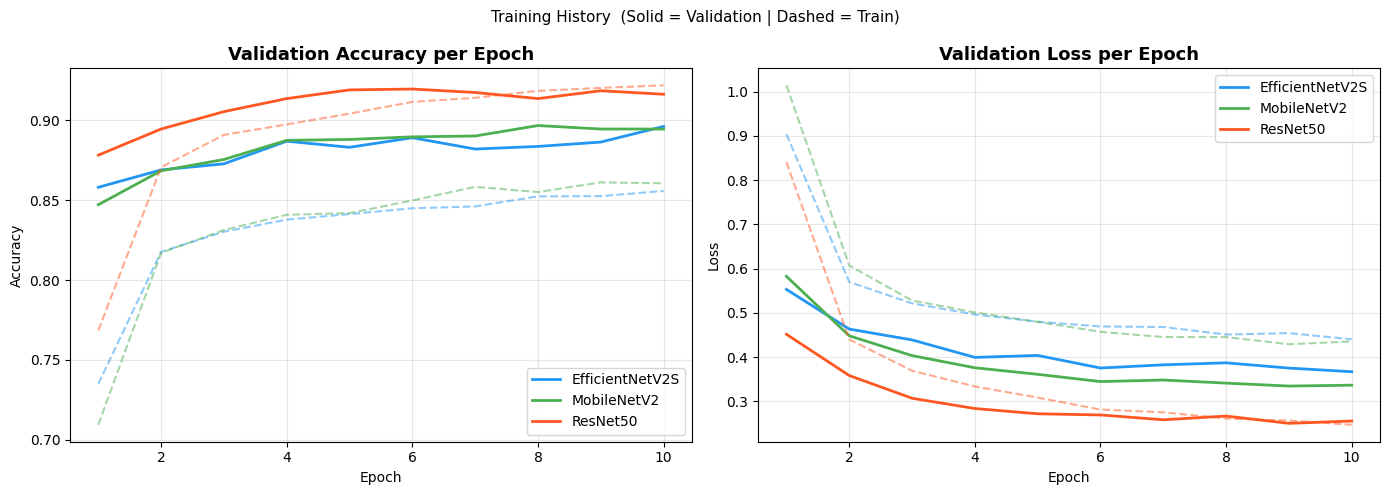

Saved: training_history.png


In [24]:
def plot_training_history(histories, model_names):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ['#2196F3', '#4CAF50', '#FF5722']

    for i, (history, name) in enumerate(zip(histories, model_names)):
        epochs = range(1, len(history['train_acc']) + 1)
        axes[0].plot(epochs, history['train_acc'], '--', color=colors[i], alpha=0.5)
        axes[0].plot(epochs, history['val_acc'],   '-',  color=colors[i], label=name, linewidth=2)
        axes[1].plot(epochs, history['train_loss'], '--', color=colors[i], alpha=0.5)
        axes[1].plot(epochs, history['val_loss'],   '-',  color=colors[i], label=name, linewidth=2)

    axes[0].set_title('Validation Accuracy per Epoch', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].set_title('Validation Loss per Epoch', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.suptitle('Training History  (Solid = Validation | Dashed = Train)', fontsize=11)
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: training_history.png')

plot_training_history(all_histories, model_names)

## Cell 12 — Confusion Matrices

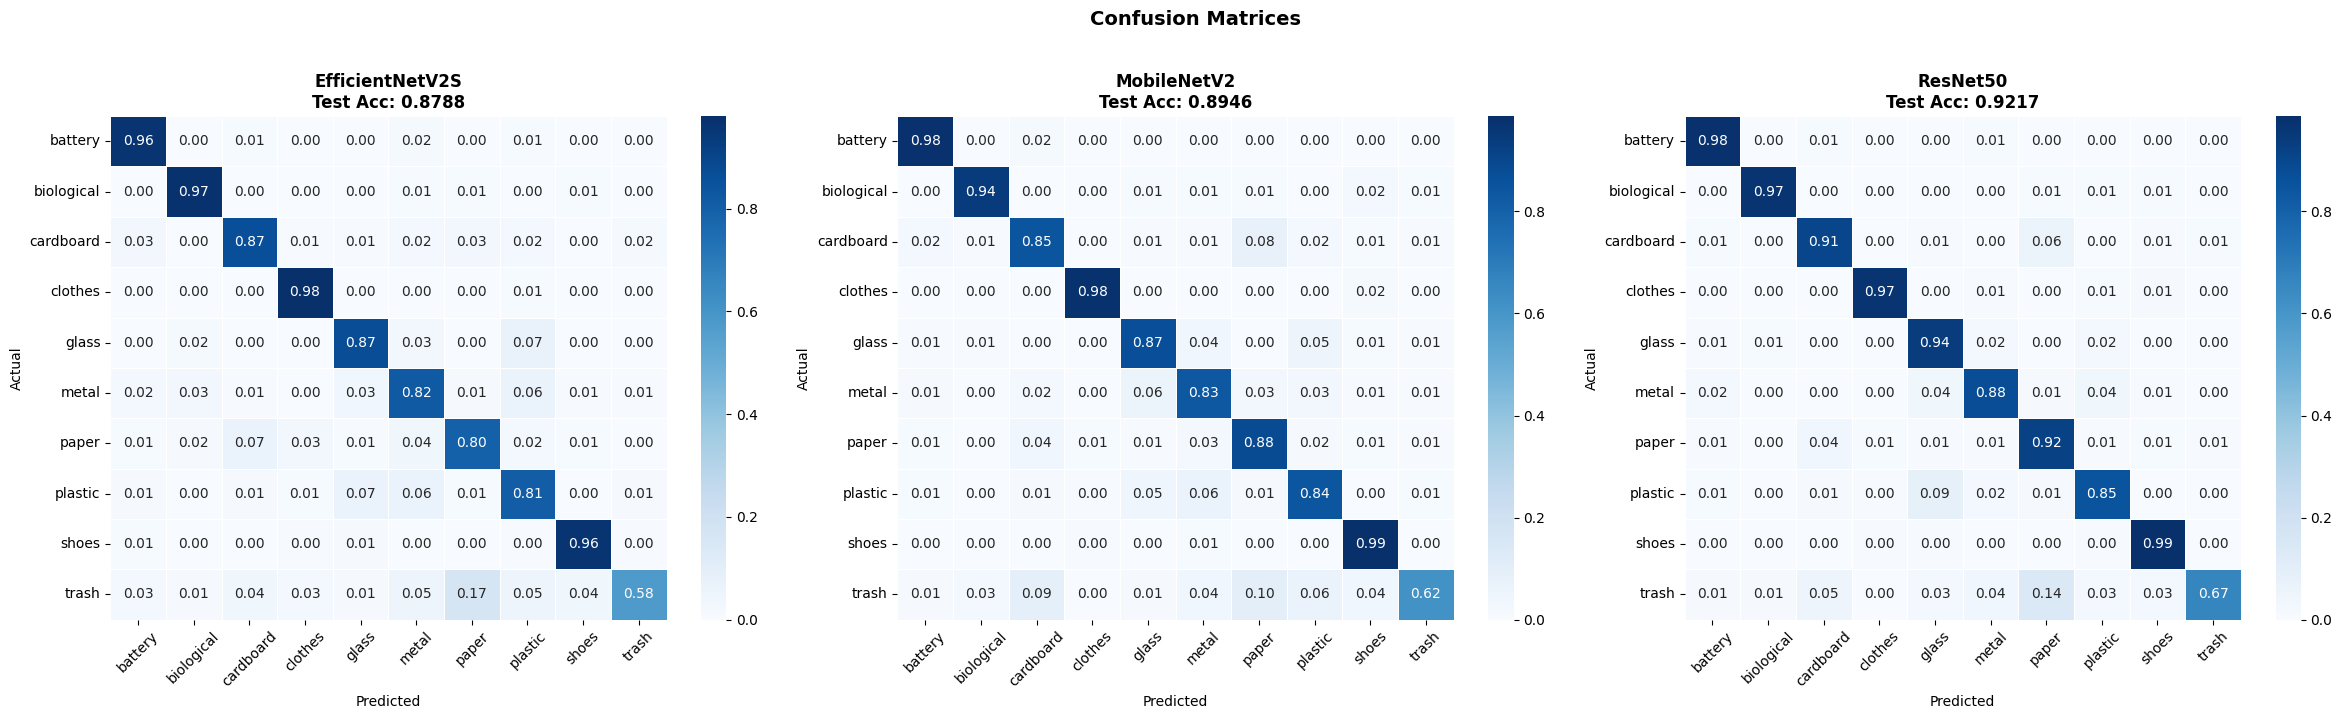

Saved: confusion_matrices.png


In [25]:
def plot_confusion_matrices(results):
    fig, axes = plt.subplots(1, len(results), figsize=(8 * len(results), 7))

    for ax, result in zip(axes, results):
        cm_norm = result['cm'].astype('float') / result['cm'].sum(axis=1, keepdims=True)
        sns.heatmap(
            cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax, linewidths=0.5
        )
        ax.set_title(f"{result['model']}\nTest Acc: {result['accuracy']:.4f}",
                     fontsize=12, fontweight='bold')
        ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
        ax.tick_params(axis='x', rotation=45)

    plt.suptitle('Confusion Matrices', fontsize=14, y=1.02, fontweight='bold')
    plt.tight_layout()
    plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: confusion_matrices.png')

plot_confusion_matrices(all_results)

## Cell 13 — Model Comparison Chart

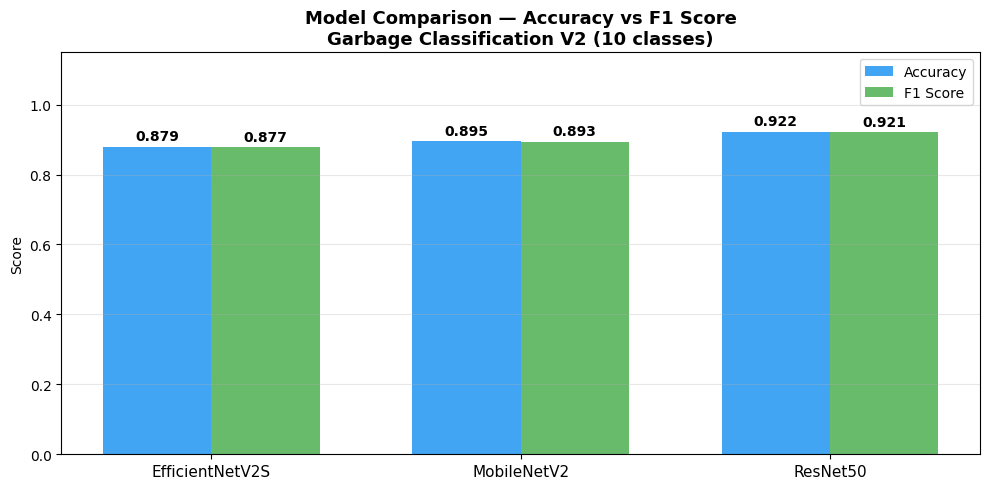

Saved: model_comparison.png


In [26]:
def plot_model_comparison(results):
    names     = [r['model']    for r in results]
    accs      = [r['accuracy'] for r in results]
    f1_scores = [r['f1']       for r in results]

    x     = np.arange(len(names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    bars1 = ax.bar(x - width/2, accs,      width, label='Accuracy', color='#2196F3', alpha=0.85)
    bars2 = ax.bar(x + width/2, f1_scores, width, label='F1 Score', color='#4CAF50', alpha=0.85)

    ax.set_title('Model Comparison — Accuracy vs F1 Score\nGarbage Classification V2 (10 classes)',
                 fontsize=13, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(names, fontsize=11)
    ax.set_ylim(0, 1.15); ax.set_ylabel('Score')
    ax.legend(); ax.grid(axis='y', alpha=0.3)

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: model_comparison.png')

plot_model_comparison(all_results)

## Cell 14 — Final Summary Table

In [27]:
print('\n' + '='*58)
print(f'{"MODEL":<20} {"ACCURACY":>10} {"F1 SCORE":>12} {"STATUS":>10}')
print('='*58)

best = max(all_results, key=lambda x: x['accuracy'])
for r in all_results:
    flag = ' BEST' if r['model'] == best['model'] else ''
    print(f"{r['model']:<20} {r['accuracy']:>10.4f} {r['f1']:>12.4f} {flag:>10}")

print('='*58)
print(f"\n Best Model  : {best['model']}")
print(f"   Accuracy    : {best['accuracy']:.4f} ({best['accuracy']*100:.2f}%)")
print(f"   F1 Score    : {best['f1']:.4f}")
print(f"\n Next step: Fine-tune {best['model']} by unfreezing deeper layers")
print(f"   Then run inference with recyclability classification layer")


MODEL                  ACCURACY     F1 SCORE     STATUS
EfficientNetV2S          0.8788       0.8775           
MobileNetV2              0.8946       0.8935           
ResNet50                 0.9217       0.9207       BEST

 Best Model  : ResNet50
   Accuracy    : 0.9217 (92.17%)
   F1 Score    : 0.9207

 Next step: Fine-tune ResNet50 by unfreezing deeper layers
   Then run inference with recyclability classification layer


## Cell 15 — Demo: Recyclability Prediction
Tests the hybrid AI system: CNN prediction + rule-based recyclability mapping

In [28]:
# Demo on a few test images using the best model
best_model_name = max(all_results, key=lambda x: x['accuracy'])['model']
best_model      = trained_models[best_model_name]

print(f'Running recyclability demo using: {best_model_name}\n')
print(f'{"CLASS":<15} {"CONFIDENCE":>12} {"RECYCLABILITY":>18}')
print('-' * 48)

_, val_test_tf = get_transforms()

# Sample one image per class for the demo
for cls in CLASS_NAMES:
    cls_path  = os.path.join(DATASET_PATH, cls)
    img_file  = os.listdir(cls_path)[5]    # pick 6th image to avoid edge cases
    img_full  = os.path.join(cls_path, img_file)

    from PIL import Image
    img_tensor = val_test_tf(Image.open(img_full).convert('RGB'))

    result = predict_with_recyclability(best_model, img_tensor)
    correct = '✅' if result['predicted_class'] == cls else '❌'
    print(f"{correct} {cls:<13} → {result['predicted_class']:<13} "
          f"{result['confidence']:>8.2%}   "
          f"{result['icon']} {result['recyclability']}")

Running recyclability demo using: ResNet50

CLASS             CONFIDENCE      RECYCLABILITY
------------------------------------------------
✅ battery       → battery         98.41%   ⚠️ SPECIAL DISPOSAL
✅ biological    → biological      94.49%   ⚫️ LANDFILL
❌ cardboard     → paper           56.47%   ♻️ RECYCLE
✅ clothes       → clothes        100.00%   ⚫️ LANDFILL
✅ glass         → glass           99.44%   ♻️ RECYCLE
✅ metal         → metal           95.26%   ♻️ RECYCLE
✅ paper         → paper           98.45%   ♻️ RECYCLE
❌ plastic       → glass           57.54%   ♻️ RECYCLE
✅ shoes         → shoes           99.98%   ⚫️ LANDFILL
❌ trash         → glass           76.14%   ♻️ RECYCLE


## Cell 16 — Fine-tune ResNet50 (all layers unfrozen, 20 epochs)

In [29]:
!pip install -q torch torchvision matplotlib scikit-learn seaborn tqdm

import os, time, copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from tqdm import tqdm

print(' Libraries imported successfully!')

 Libraries imported successfully!


In [30]:
# Load & Fine-tune ResNet50 from saved weights 
# Restore LEARNING_RATE to fine-tuning value
LEARNING_RATE = 1e-4
NUM_EPOCHS    = 20

# Load ResNet50 architecture and saved weights
fine_tune_model = build_resnet50(NUM_CLASSES)
fine_tune_model.load_state_dict(
    torch.load('/kaggle/working/ResNet50_weights.pth', map_location=DEVICE)
)
fine_tune_model = fine_tune_model.to(DEVICE)
print(' Loaded ResNet50 weights from /kaggle/working/ResNet50_weights.pth')

# Unfreeze ALL layers
for param in fine_tune_model.parameters():
    param.requires_grad = True
print(f' All layers unfrozen — trainable params: '
      f'{sum(p.numel() for p in fine_tune_model.parameters() if p.requires_grad):,}')

# Train
fine_tuned_model, ft_history = train_model(
    fine_tune_model, 'ResNet50_FineTuned',
    train_loader, val_loader
)

# Evaluate
ft_result = evaluate_model(fine_tuned_model, test_loader, 'ResNet50_FineTuned')

# Save
torch.save(fine_tuned_model.state_dict(), '/kaggle/working/ResNet50_FineTuned_weights.pth')
print('Saved: ResNet50_FineTuned_weights.pth')

# Restore globals
LEARNING_RATE = 0.001
NUM_EPOCHS    = 10

ResNet50        — Trainable params: 20,490
 Loaded ResNet50 weights from /kaggle/working/ResNet50_weights.pth
 All layers unfrozen — trainable params: 23,528,522

  Training: ResNet50_FineTuned


Epoch  1/20 | Train Loss: 0.2251 Acc: 0.9247 | Val Loss: 0.1938 Acc: 0.9331 | Time: 108.1s


Epoch  2/20 | Train Loss: 0.1196 Acc: 0.9612 | Val Loss: 0.1767 Acc: 0.9472 | Time: 107.6s


Epoch  3/20 | Train Loss: 0.0802 Acc: 0.9746 | Val Loss: 0.1603 Acc: 0.9576 | Time: 107.9s


Epoch  4/20 | Train Loss: 0.0616 Acc: 0.9803 | Val Loss: 0.1707 Acc: 0.9489 | Time: 107.5s


...

Epoch 17/20 | Train Loss: 0.0078 Acc: 0.9977 | Val Loss: 0.1615 Acc: 0.9554 | Time: 107.5s


Epoch 18/20 | Train Loss: 0.0072 Acc: 0.9979 | Val Loss: 0.1619 Acc: 0.9592 | Time: 107.1s


Epoch 19/20 | Train Loss: 0.0056 Acc: 0.9984 | Val Loss: 0.1655 Acc: 0.9614 | Time: 107.4s


Epoch 20/20 | Train Loss: 0.0067 Acc: 0.9981 | Val Loss: 0.1602 Acc: 0.9603 | Time: 107.5s

Best Val Accuracy [ResNet50_FineTuned]: 0.9625 (96.25%)



ResNet50_FineTuned — Test Results
   Accuracy  : 0.9614 (96.14%)
   F1 Score  : 0.9611

Classification Report:
              precision    recall  f1-score   support

     battery       0.98      1.00      0.99       108
  biological       0.97      0.99      0.98       101
   cardboard       0.96      0.96      0.96       183
     clothes       0.99      0.98      0.99       298
       glass       0.98      0.96      0.97       284
       metal       0.91      0.94      0.93       145
       paper       0.91      0.97      0.94       196
     plastic       0.94      0.94      0.94       222
       shoes       0.99      0.99      0.99       225
       trash       0.94      0.77      0.85        78

    accuracy                           0.96      1840
   macro avg       0.96      0.95      0.95      1840
weighted avg       0.96      0.96      0.96      1840

Saved: ResNet50_FineTuned_weights.pth


## Cell 17 - Baseline vs fine-tuned comparison chart


MODEL                          ACCURACY   F1 SCORE     GAIN
ResNet50 (frozen head)           0.9217     0.9207
ResNet50 (fine-tuned)            0.9614     0.9611  +0.0397


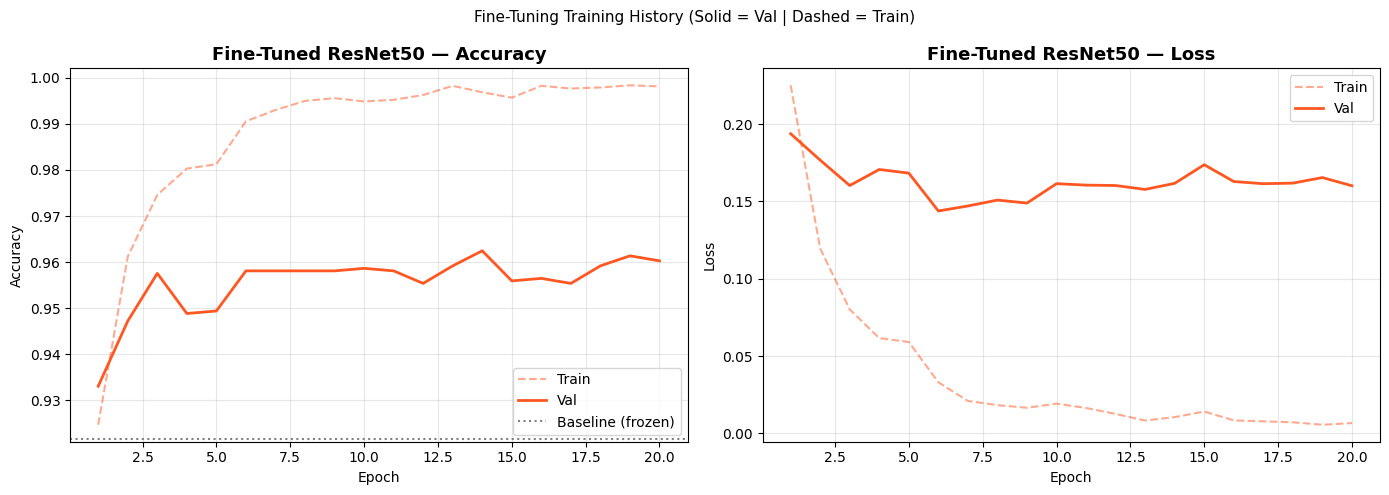

Saved: finetuned_history.png


In [31]:
#Baseline vs Fine-Tuned Comparison

baseline_acc = 0.9217   # from your earlier run
baseline_f1  = 0.9207

print('\n' + '='*62)
print(f'{"MODEL":<28} {"ACCURACY":>10} {"F1 SCORE":>10} {"GAIN":>8}')
print('='*62)
print(f'{"ResNet50 (frozen head)":<28} {baseline_acc:>10.4f} {baseline_f1:>10.4f}')
print(f'{"ResNet50 (fine-tuned)":<28} '
      f'{ft_result["accuracy"]:>10.4f} '
      f'{ft_result["f1"]:>10.4f} '
      f'{ft_result["accuracy"] - baseline_acc:>+8.4f}')
print('='*62)

# Plot fine-tuning curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, len(ft_history['train_acc']) + 1)

axes[0].plot(epochs, ft_history['train_acc'], '--', color='#FF5722', alpha=0.5, label='Train')
axes[0].plot(epochs, ft_history['val_acc'],   '-',  color='#FF5722', linewidth=2, label='Val')
axes[0].axhline(y=baseline_acc, color='gray', linestyle=':', linewidth=1.5, label='Baseline (frozen)')
axes[0].set_title('Fine-Tuned ResNet50 — Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, ft_history['train_loss'], '--', color='#FF5722', alpha=0.5, label='Train')
axes[1].plot(epochs, ft_history['val_loss'],   '-',  color='#FF5722', linewidth=2, label='Val')
axes[1].set_title('Fine-Tuned ResNet50 — Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Fine-Tuning Training History (Solid = Val | Dashed = Train)', fontsize=11)
plt.tight_layout()
plt.savefig('finetuned_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: finetuned_history.png')

## Cell 18 - Live batch demo with top-3 uncertainty breakdown

In [32]:
def run_full_demo(model, test_loader):
    model.eval()
    # Grab one batch from test loader
    images, labels = next(iter(test_loader))
    images = images.to(DEVICE)
    with torch.no_grad():
        outputs = model(images)
        probs   = torch.softmax(outputs, dim=1)
    confs, preds = probs.max(1)
    print(' Smart Waste Sorting System — Live Test Set Predictions')
    print('='*72)
    print(f'{"ACTUAL":<15} {"PREDICTED":<15} {"CONFIDENCE":>10} {"DISPOSAL":>20} {"OK"}')
    print('='*72)
    correct = 0
    n_show  = min(32, len(labels))
    for i in range(n_show):
        actual        = CLASS_NAMES[labels[i].item()]
        predicted     = CLASS_NAMES[preds[i].item()]
        confidence    = confs[i].item()
        recyclability, icon = RECYCLABILITY_MAP.get(predicted, ('UNKNOWN', '❓'))
        is_right      = actual == predicted
        correct      += int(is_right)
        status        = '✅' if is_right else '❌'
        print(f'{actual:<15} {predicted:<15} {confidence:>9.1%} '
              f'{icon} {recyclability:<17} {status}')
    print('='*72)
    print(f'\nBatch Demo Accuracy : {correct}/{n_show} ({correct/n_show:.0%})')

    # Top-3 for most uncertain prediction (most interesting for report)
    uncertainties       = 1 - confs[:n_show]
    most_uncertain_idx  = uncertainties.argmax().item()
    actual_uncertain    = CLASS_NAMES[labels[most_uncertain_idx].item()]
    predicted_uncertain = CLASS_NAMES[preds[most_uncertain_idx].item()]
    print(f'\n📊 Top-3 for most uncertain prediction'
          f' (sample {most_uncertain_idx} — actual: {actual_uncertain}'
          f', predicted: {predicted_uncertain}):')
    top3_probs, top3_idx = torch.topk(probs[most_uncertain_idx], 3)
    for cls_name, prob in zip([CLASS_NAMES[i] for i in top3_idx], top3_probs.cpu()):
        bar = '█' * int(prob.item() * 30)
        print(f'   {cls_name:<12}: {prob.item():>6.1%}  {bar}')

    # Disposal legend
    print('\n♻️  DISPOSAL CATEGORY LEGEND')
    print('-'*45)
    recycle  = [c for c, v in RECYCLABILITY_MAP.items() if v[0] == 'RECYCLE']
    landfill = [c for c, v in RECYCLABILITY_MAP.items() if v[0] == 'LANDFILL']
    special  = [c for c, v in RECYCLABILITY_MAP.items() if v[0] == 'SPECIAL DISPOSAL']
    print(f'  ♻️  RECYCLE          : {", ".join(recycle)}')
    print(f'  ⭕️  LANDFILL         : {", ".join(landfill)}')
    print(f'  ⚠️  SPECIAL DISPOSAL : {", ".join(special)}')

run_full_demo(fine_tuned_model, test_loader)

 Smart Waste Sorting System — Live Test Set Predictions
ACTUAL          PREDICTED       CONFIDENCE             DISPOSAL OK
plastic         plastic             98.0% ♻️ RECYCLE           ✅
cardboard       cardboard          100.0% ♻️ RECYCLE           ✅
paper           paper              100.0% ♻️ RECYCLE           ✅
cardboard       cardboard          100.0% ♻️ RECYCLE           ✅
trash           trash               99.9% ⚫️ LANDFILL          ✅
shoes           shoes              100.0% ⚫️ LANDFILL          ✅
paper           paper               99.8% ♻️ RECYCLE           ✅
plastic         plastic            100.0% ♻️ RECYCLE           ✅
glass           glass              100.0% ♻️ RECYCLE           ✅
shoes           shoes              100.0% ⚫️ LANDFILL          ✅
glass           glass              100.0% ♻️ RECYCLE           ✅
glass           glass              100.0% ♻️ RECYCLE           ✅
plastic         plastic            100.0% ♻️ RECYCLE           ✅
cardboard       cardboard       

## Cell 19 - Fine-tuned confusion matrix

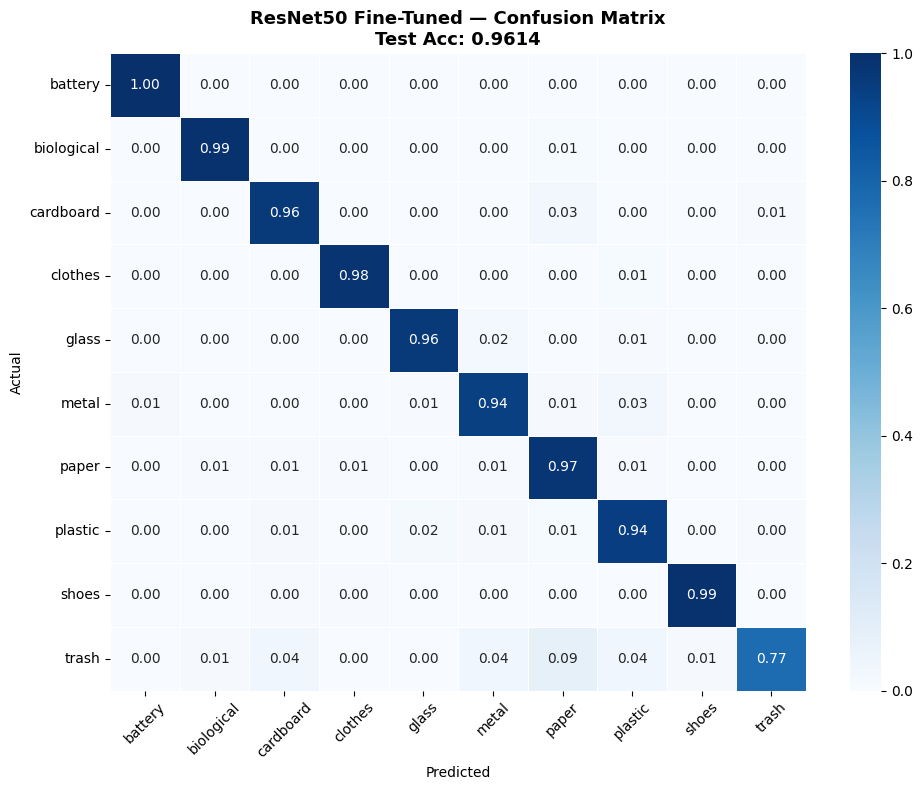

Saved: finetuned_confusion_matrix.png


In [33]:
#Confusion Matrix — Fine-Tuned ResNet50

ft_cm_result = {
    'model'    : 'ResNet50_FineTuned',
    'accuracy' : ft_result['accuracy'],
    'cm'       : ft_result['cm']
}

fig, ax = plt.subplots(figsize=(10, 8))
cm_norm = ft_result['cm'].astype('float') / ft_result['cm'].sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=ax, linewidths=0.5
)
ax.set_title(f'ResNet50 Fine-Tuned — Confusion Matrix\nTest Acc: {ft_result["accuracy"]:.4f}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('finetuned_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: finetuned_confusion_matrix.png')

## Cell 20 - Save final model (`SmartWasteSorter_Final.pth`) + report checklist

In [34]:
#Save Final Model + Full Report Checklist

torch.save({
    'model_state_dict'  : fine_tuned_model.state_dict(),
    'class_names'       : CLASS_NAMES,
    'recyclability_map' : RECYCLABILITY_MAP,
    'test_accuracy'     : ft_result['accuracy'],
    'f1_score'          : ft_result['f1'],
}, '/kaggle/working/SmartWasteSorter_Final.pth')

print('💾 Final model saved: SmartWasteSorter_Final.pth')
print()
print('='*58)
print('📋 FINAL REPORT CHECKLIST')
print('='*58)
print(f'   Dataset        : Garbage Classification V2')
print(f'                     12,259 images | 10 classes')
print(f'   Split          : 70% train | 15% val | 15% test')
print(f'   Augmentation   : Flip, Rotate, ColorJitter (train only)')
print(f'   Model 1        : EfficientNetV2S  — Acc: 87.88% | F1: 0.8775')
print(f'   Model 2        : MobileNetV2      — Acc: 89.46% | F1: 0.8935')
print(f'   Model 3        : ResNet50         — Acc: 92.17% | F1: 0.9207')
print(f'   Best Baseline  : ResNet50 (frozen head)')
print(f'   Fine-Tuned     : ResNet50         — Acc: {ft_result["accuracy"]*100:.2f}% | F1: {ft_result["f1"]:.4f}')
print(f'   Hybrid AI      : CNN + Rule-based recyclability map')
print(f'   Disposal cats  : RECYCLE / LANDFILL / SPECIAL DISPOSAL')
print(f'   Weights saved  : SmartWasteSorter_Final.pth')
print('='*58)

💾 Final model saved: SmartWasteSorter_Final.pth

📋 FINAL REPORT CHECKLIST
   Dataset        : Garbage Classification V2
                     12,259 images | 10 classes
   Split          : 70% train | 15% val | 15% test
   Augmentation   : Flip, Rotate, ColorJitter (train only)
   Model 1        : EfficientNetV2S  — Acc: 87.88% | F1: 0.8775
   Model 2        : MobileNetV2      — Acc: 89.46% | F1: 0.8935
   Model 3        : ResNet50         — Acc: 92.17% | F1: 0.9207
   Best Baseline  : ResNet50 (frozen head)
   Fine-Tuned     : ResNet50         — Acc: 96.14% | F1: 0.9611
   Hybrid AI      : CNN + Rule-based recyclability map
   Disposal cats  : RECYCLE / LANDFILL / SPECIAL DISPOSAL
   Weights saved  : SmartWasteSorter_Final.pth


## Cell 21 - Inference on custom images from Kaggle input

In [35]:
import os

def get_all_image_paths(base_path):
    image_paths = []
    
    for root, _, files in os.walk(base_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                full_path = os.path.join(root, file)
                image_paths.append(full_path)
    
    return image_paths

IMAGE_PATHS = get_all_image_paths('/kaggle/input')

print(f"Total images found: {len(IMAGE_PATHS)}\n")

# Preview first few paths
for path in IMAGE_PATHS[:10]:
    print(path)

Total images found: 5

/kaggle/input/datasets/shubasrinivas/glass-img/glass.png
/kaggle/input/datasets/shubasrinivas/plastic/plastic.jpg
/kaggle/input/datasets/shubasrinivas/cardboard-image/Box.jpg
/kaggle/input/datasets/shubasrinivas/clothes/clothes.jpg
/kaggle/input/datasets/shubasrinivas/paper-image/paper.jpg


  File       : Box.jpg
  Predicted  : PAPER
  Confidence : 97.01%
  Disposal   : ♻️ RECYCLE

  File       : glass.png
  Predicted  : GLASS
  Confidence : 99.93%
  Disposal   : ♻️ RECYCLE

  File       : paper.jpg
  Predicted  : PAPER
  Confidence : 99.96%
  Disposal   : ♻️ RECYCLE

  File       : plastic.jpg
  Predicted  : PLASTIC
  Confidence : 99.95%
  Disposal   : ♻️ RECYCLE

  File       : clothes.jpg
  Predicted  : CLOTHES
  Confidence : 97.22%
  Disposal   : ⚫️ LANDFILL



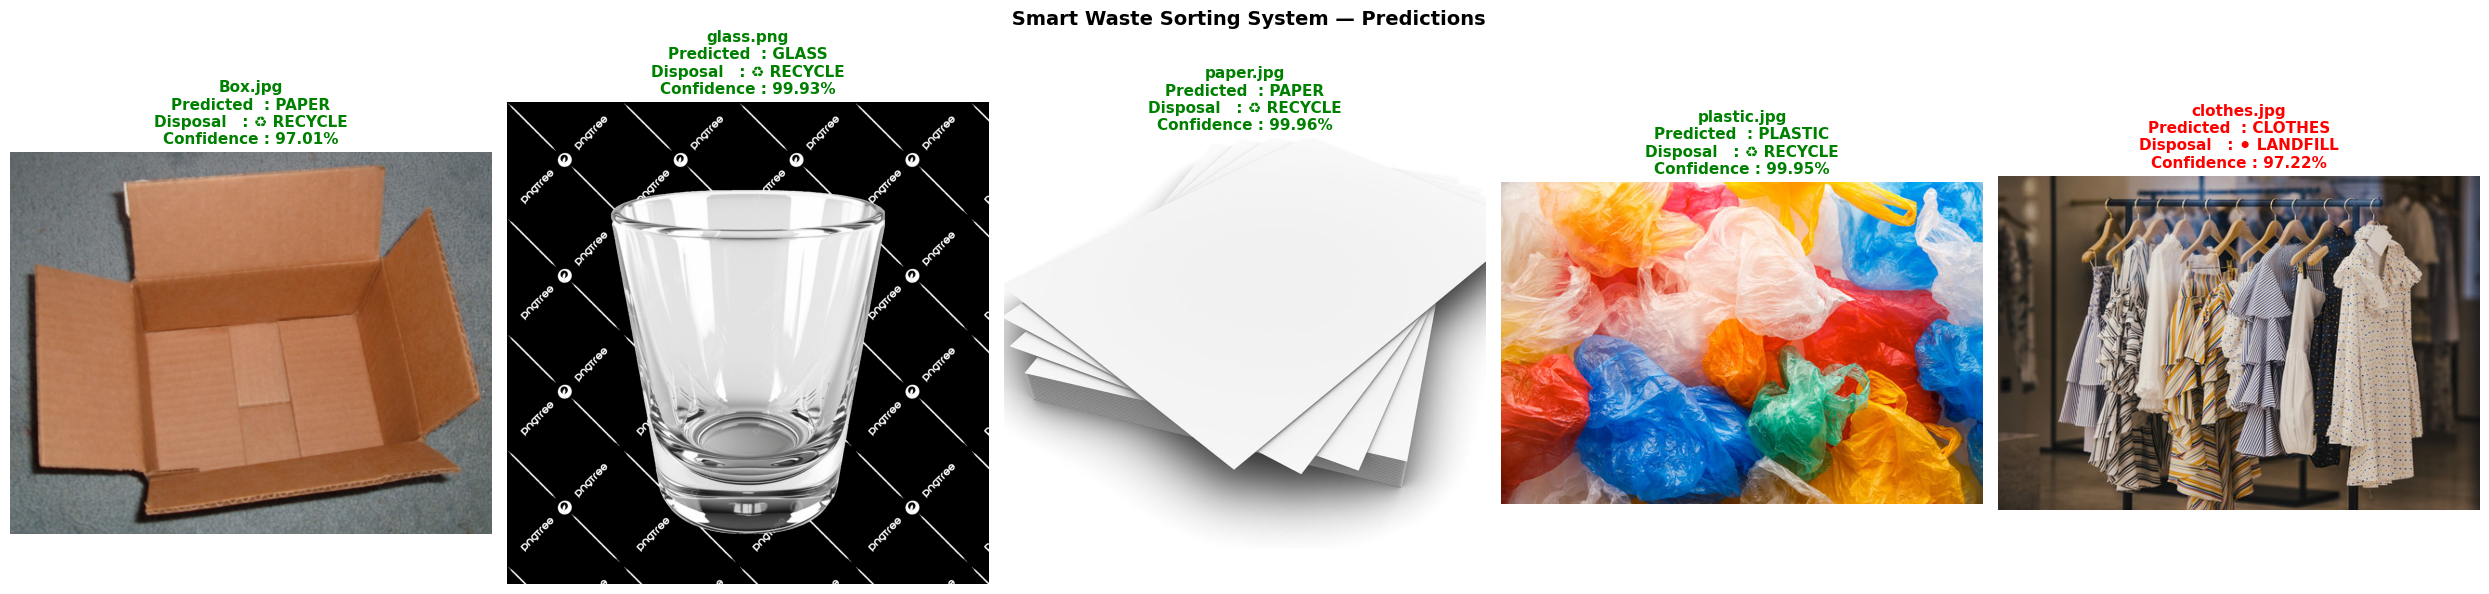

Saved: all_predictions.png


In [36]:
#Test All Images from Kaggle Input 
import warnings
warnings.filterwarnings("ignore")

from PIL import Image
import torch
import os
import matplotlib.pyplot as plt

#All your input images
IMAGE_PATHS = [
    '/kaggle/input/datasets/shubasrinivas/cardboard-image/Box.jpg',
    '/kaggle/input/datasets/shubasrinivas/glass-img/glass.png',
    '/kaggle/input/datasets/shubasrinivas/paper-image/paper.jpg',
    '/kaggle/input/datasets/shubasrinivas/plastic/plastic.jpg',
    '/kaggle/input/datasets/shubasrinivas/clothes/clothes.jpg',
]

_, val_test_tf = get_transforms()

fig, axes = plt.subplots(1, len(IMAGE_PATHS), figsize=(5 * len(IMAGE_PATHS), 6))

for ax, full_path in zip(axes, IMAGE_PATHS):
    img        = Image.open(full_path).convert('RGB')
    img_tensor = val_test_tf(img)

    # Run prediction 
    result = predict_with_recyclability(fine_tuned_model, img_tensor)

    #Colour by disposal category
    color = ('green'  if result['recyclability'] == 'RECYCLE'
        else 'red'    if result['recyclability'] == 'LANDFILL'
        else 'orange')

    ax.imshow(img)
    ax.axis('off')
    ax.set_title(
        f"{os.path.basename(full_path)}\n"
        f"Predicted  : {result['predicted_class'].upper()}\n"
        f"Disposal   : {result['icon']} {result['recyclability']}\n"
        f"Confidence : {result['confidence']:.2%}",
        fontsize=11, fontweight='bold', color=color
    )

    print(f'{"="*50}')
    print(f'  File       : {os.path.basename(full_path)}')
    print(f'  Predicted  : {result["predicted_class"].upper()}')
    print(f'  Confidence : {result["confidence"]:.2%}')
    print(f'  Disposal   : {result["icon"]} {result["recyclability"]}')
    print(f'{"="*50}\n')

plt.suptitle(' Smart Waste Sorting System — Predictions',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('all_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: all_predictions.png')